--- Optimization Results ---
Optimal Point:   x = 0.5000, y = 0.5000
Minimum Value:   f(x,y) = 0.5000
Lagrange Multiplier (lambda): -1.0000


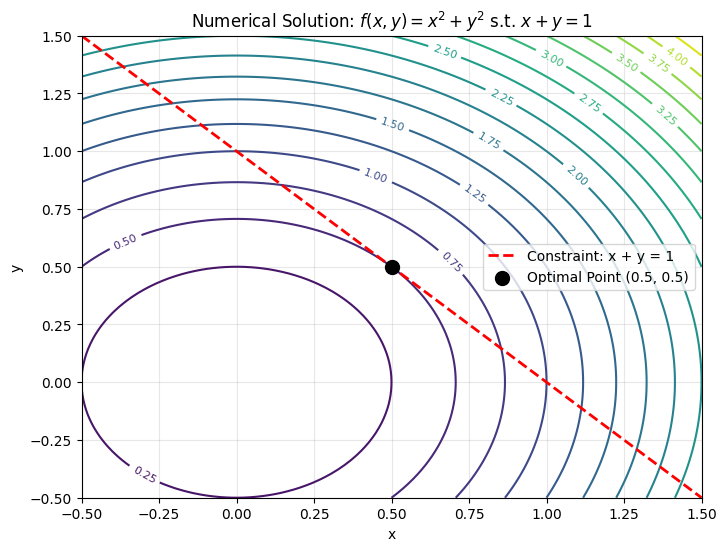

'\n# 1. Calculate the gradient of the objective at the solution\n# For f = x^2 + y^2, grad_f = [2x, 2y]\ngrad_f = np.array([2*x_opt, 2*y_opt])\n\n# 2. Calculate the gradient of the constraint at the solution\n# For g = x + y - 1, grad_g = [1, 1]\ngrad_g = np.array([1, 1])\n\n# 3. Solve for lambda: grad_f = -lambda * grad_g\n# (Note: the sign depends on your Lagrangian definition)\nlambda_recovered = -grad_f[0] / grad_g[0] \n\nprint(f"Manually recovered lambda: {lambda_recovered}")\n'

In [ ]:
"""
Created on Wed Jan 21 11:04:12 2026

@author: Dr. Vaibhav Kumar
Assistant Professor, DSE, IISERB

Code explanation

minimize(objective, initial_guess, constraints=cons)

This is the engine. It uses the SLSQP (Sequential Least Squares Programming) algorithm by default when constraints are provided. It iterates through points until it finds where the gradient of the objective and the gradient of the constraint align.

The Constraint dictionary
  {'type': 'eq', 'fun': constraint} tells the solver to find the minimum of the objective, but only look at points where constraint function returns 0.


"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Define the Objective Function f(x, y) = x^2 + y^2
def objective(vars):
    x, y = vars
    return x**2 + y**2

# 2. Define the Equality Constraint g(x, y) = x + y - 1 = 0
def constraint(vars):
    x, y = vars
    return x + y - 1

# 3. Setup the Constraint for SciPy
cons = {'type': 'eq', 'fun': constraint}

# 4. Run the Optimizer
'''
Initial guess
    Even for simple problems, solvers need a starting point. We chose [0, 0], but for this specific "convex" problem, almost any starting point would lead to the same result.
   Exercise1: check for other non convex functions
   Exercise2: apply non-Linear constraints
'''
initial_guess = [0, 0]
solution = minimize(
    objective,
    initial_guess,
    method='trust-constr',
    constraints=cons
)

# 5. Extract Results
x_opt, y_opt = solution.x
# solution.v is a list of arrays. [0] gets the first constraint block,
# [0] gets the first multiplier in that block.
lam = solution.v[0][0]

print(f"--- Optimization Results ---")
print(f"Optimal Point:   x = {x_opt:.4f}, y = {y_opt:.4f}")
print(f"Minimum Value:   f(x,y) = {solution.fun:.4f}")
print(f"Lagrange Multiplier (lambda): {lam:.4f}")

# --- Visualization ---
x_range = np.linspace(-0.5, 1.5, 100)
y_range = np.linspace(-0.5, 1.5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = X**2 + Y**2

plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# Plot the constraint line: x + y = 1 => y = 1 - x
x_line = np.linspace(-0.5, 1.5, 100)
y_line = 1 - x_line
plt.plot(x_line, y_line, 'r--', label="Constraint: x + y = 1", linewidth=2)

# Mark the optimal point
plt.scatter(x_opt, y_opt, color='black', s=100, zorder=5,
            label=f"Optimal Point ({x_opt:.1f}, {y_opt:.1f})")

plt.title("Numerical Solution: $f(x,y) = x^2 + y^2$ s.t. $x+y=1$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


'''
# 1. Calculate the gradient of the objective at the solution
# For f = x^2 + y^2, grad_f = [2x, 2y]
grad_f = np.array([2*x_opt, 2*y_opt])# 1. Calculate the gradient of the objective at the solution
# For f = x^2 + y^2, grad_f = [2x, 2y]
…print(f"Manually recovered lambda: {lambda_recovered}")
'''

# 2. Calculate the gradient of the constraint at the solution
# For g = x + y - 1, grad_g = [1, 1]
grad_g = np.array([1, 1])

# 3. Solve for lambda: grad_f = -lambda * grad_g
# (Note: the sign depends on your Lagrangian definition)
lambda_recovered = -grad_f[0] / grad_g[0]

print(f"Manually recovered lambda: {lambda_recovered}")

